# Análise de Manutenção Preditiva Industrial

Objetivo: Prever falhas em máquinas industriais usando dados de sensores.

Tipo de problema: Classificação binária (falhou = 1 / não falhou = 0)

In [3]:
# Pandas: manipulação de tabelas (DataFrames). É a base de qualquer projeto de dados.
import pandas as pd

# NumPy: cálculos numéricos e arrays. Base matemática do Pandas.
import numpy as np

# Matplotlib: biblioteca para criar gráficos.
import matplotlib.pyplot as plt

# Seaborn: gráficos estatísticos bonitos, construído sobre o Matplotlib.
import seaborn as sns

In [4]:
# Lê o arquivo CSV e cria um DataFrame (tabela) chamado 'df'.
# 'df' é o padrão de mercado para nomear DataFrames em pandas.
df = pd.read_csv("manutencao_preditiva.csv")

## Fase 1: Análise Exploratória (EDA)

In [10]:
# .head(5) mostra as 5 primeiras linhas do DataFrame.
# Usado para inspecionar rapidamente a estrutura dos dados.
df.head(5)

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [13]:
# Verifica o tamanho do dataset: (linhas, colunas)
# Base para dimensionar todo o restante da análise.
print("---- Tamanho do dataset ----")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

---- Tamanho do dataset ----
Número de linhas: 10000
Número de colunas: 14


In [22]:
# Resumo técnico das colunas: tipo de dado, quantidade de não-nulos e memória usada.
# Já detecta valores faltantes e tipos inesperados.

print("--- Resumo das Colunas e Tipos ----\n-")

df.info()

print("\n---- Valores Faltantes por Coluna ---")
df.isnull().sum()


--- Resumo das Colunas e Tipos ----
-
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
d

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

## Análise Estatística Descritiva

In [24]:
# Estatísticas descritivas das colunas numéricas.
# Revela escala, dispersão e possíveis outliers das variáveis.
print("---- Estatísticas Descritivas ----\n")
df.describe()


---- Estatísticas Descritivas ----



,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Distribuição das Variáveis Numéricas — Histogramas

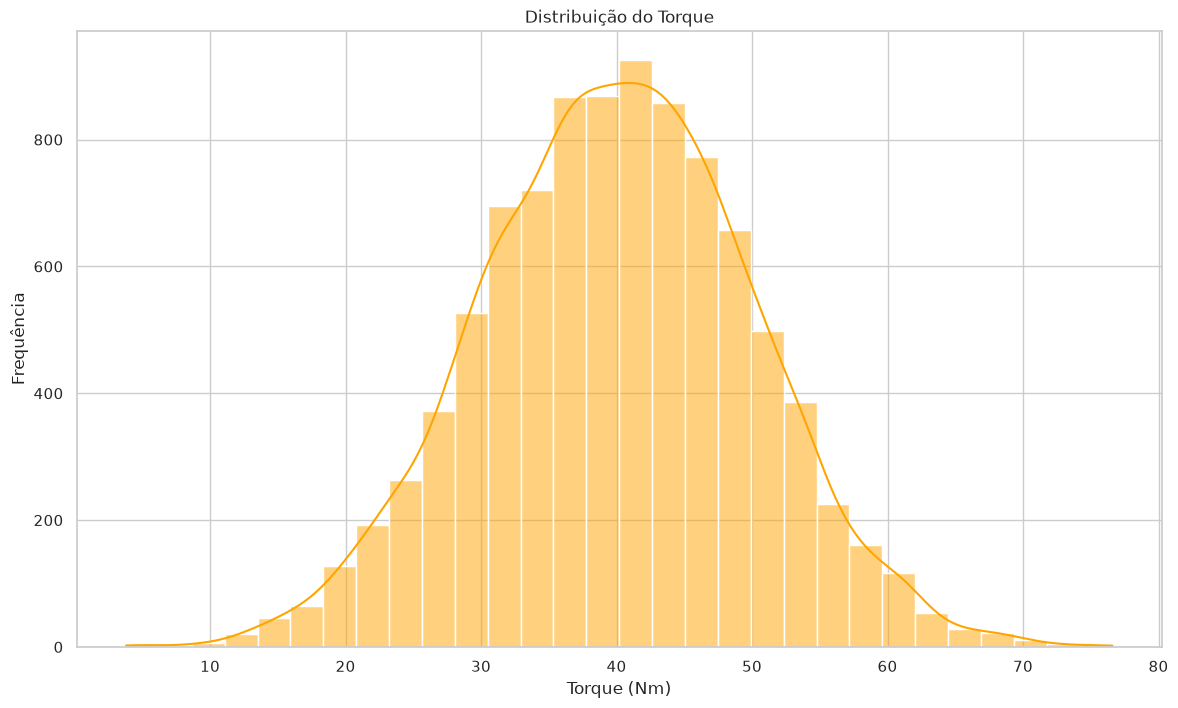

In [39]:
# Histograma para ver a distribuição do torque nas máquinas.
# Escolhemos o torque porque é uma das variáveis mais relacionadas a falhas mecânicas.

sns.histplot(data=df, x='torque_nm', bins=30, kde=True, color='orange')
plt.title('Distribuição do Torque')
plt.xlabel('Torque (Nm)')
plt.ylabel('Frequência')
plt.show()

## Desbalanceamento da Variável Alvo

/tmp/ipykernel_9574/3661227793.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='falha_maquina', palette='Set2')


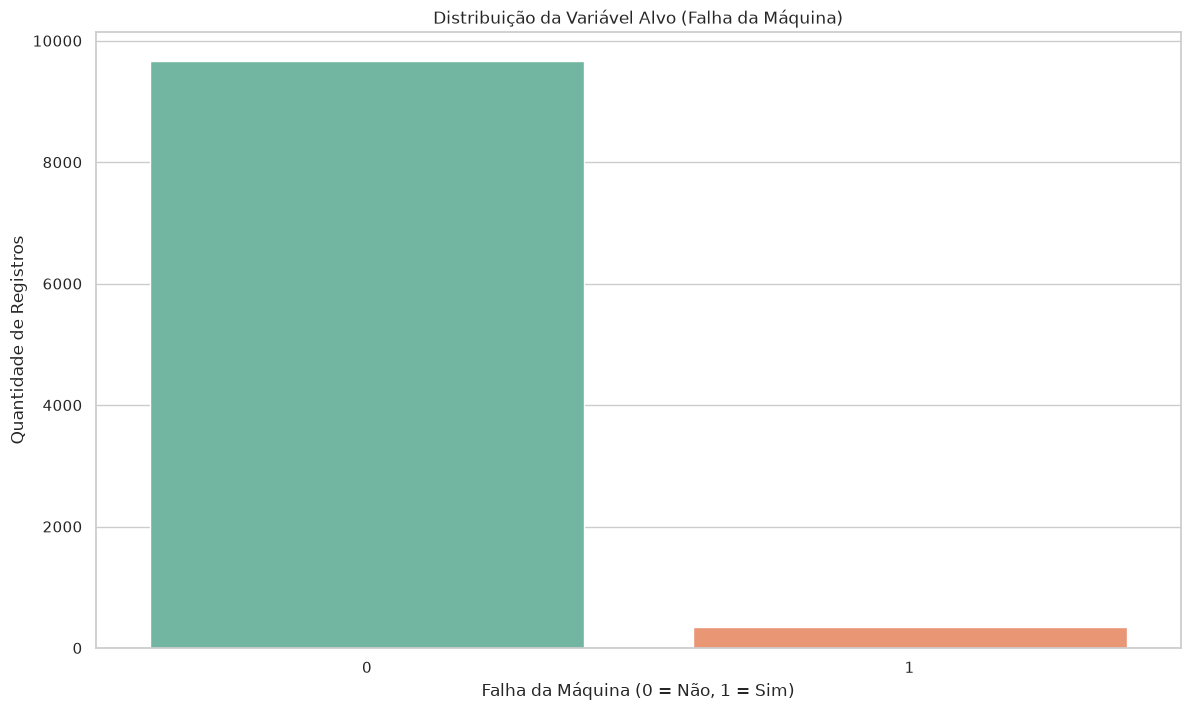

In [41]:
sns.countplot(data=df, x='falha_maquina', palette='Set2')
plt.title('Distribuição da Variável Alvo (Falha da Máquina)')
plt.xlabel('Falha da Máquina (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Registros')
plt.show()

## Correlação entre as Variáveis Numéricas — Heatmap de Pearson

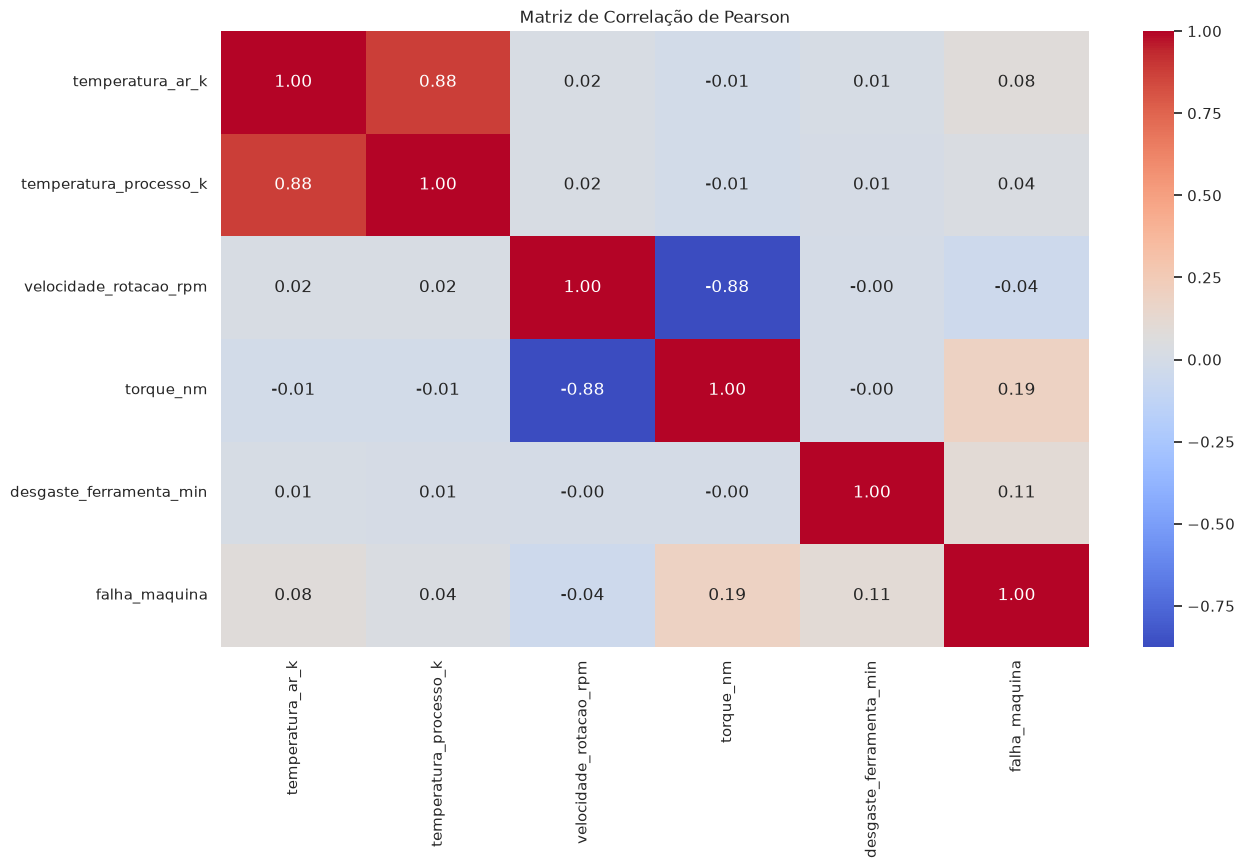

In [42]:
# Seleciona appenas as variáveis numéricas relevantes ( sensores + alvo ) para a análise de correlação.
# Exclui id_produto, udi e as colunas de tipo de falha (Não são poreditores válidos)

colunas_analise = ['temperatura_ar_k', 'temperatura_processo_k', 
                   'velocidade_rotacao_rpm', 'torque_nm',
                   'desgaste_ferramenta_min', 'falha_maquina']

# Calcular a matriz de correlação de Pearson entre essas variáveis.

matriz_correlacao = df[colunas_analise].corr(method='pearson')

# Criar um heatmap para visualizar a matriz de correlação.
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação de Pearson')
plt.show()

## Conclusão da Fase 1 — Diagnóstico e Direcionamento

A análise exploratória revelou três padrões importantes que direcionam
toda a estratégia de modelagem nas próximas fases.

### Distribuição das variáveis preditoras

A distribuição do torque é aproximadamente **normal**, com concentração
em torno de 40 Nm. Isso sugere que a operação padrão da fábrica está
dentro de uma faixa estável. Valores muito abaixo ou muito acima são
raros e podem estar associados a falhas — o que reforça a hipótese de
que **valores extremos** são candidatos naturais a preditores da
variável alvo.

### Desbalanceamento severo da variável alvo

Este é o achado mais crítico do diagnóstico. Das 10.000 máquinas do
dataset, apenas **3,4% falharam** (339 registros), enquanto **96,6%
operaram normalmente** (9.661 registros). Este desbalanceamento tem
duas implicações diretas para a modelagem:

- Um modelo ingênuo pode simplesmente prever "não falha" para todos os
casos e ainda assim atingir 96,6% de acurácia, sem nunca detectar uma
falha real — que é justamente o que o negócio precisa identificar.
- **Acurácia sozinha não é confiável** como métrica principal neste
projeto.

**Decisão:** aplicarei a técnica **SMOTE** no conjunto de treino durante
a Fase 3 (Modelagem) para balancear as classes, e priorizarei métricas
como **Recall** e **F1-score** na avaliação final, em vez de acurácia
isolada.

### Correlações entre variáveis

O heatmap de correlação de Pearson revelou três insights:

- **Alta correlação positiva (0,88)** entre `temperatura_ar_k` e
`temperatura_processo_k`, indicando possível **multicolinearidade** —
elas medem essencialmente o mesmo fenômeno térmico.
- **Alta correlação negativa (-0,88)** entre
`velocidade_rotacao_rpm` e `torque_nm`. Isso é fisicamente esperado:
quanto maior a rotação, menor o torque (comportamento natural de
motores elétricos).
- **Nenhuma variável isolada** apresenta correlação forte com a
variável alvo `falha_maquina`. A maior correlação é do torque (0,19),
ainda considerada fraca em termos estatísticos.

**Decisão:** como nenhuma variável sozinha é fortemente preditiva, o
modelo precisará aprender **padrões combinados** entre as variáveis, o
que exige algoritmos capazes de capturar não linearidades — reforçando
a escolha de comparar KNN, Árvore de Decisão e Regressão Logística.

### Diferenças de escala

A análise de `.describe()` mostrou que as variáveis operam em escalas
muito diferentes — velocidade na casa dos milhares, torque na casa das
dezenas.

**Decisão:** aplicarei **padronização (StandardScaler)** antes de
treinar o KNN, pois este algoritmo é sensível a diferenças de escala.